# English Premier League VAR Analysis
## Part 2 - Team Impact Analysis

### Overview
This notebook analyzes the impact of VAR (Video Assistant Referee) decisions on Premier League clubs across multiple seasons (2019-2025).

### Questions Explored
1. **Winners & Losers**: Which teams benefit most/least from VAR?
2. **Consistency**: Are VAR impacts consistent across seasons or highly variable?
3. **Big 6 Analysis**: Do "Big 6" clubs receive favorable treatment?
4. **Goal Impact**: How do VAR decisions affect goal tallies?
5. **Trends Over Time**: Has VAR impact changed since its introduction?

### Data Source
- `data/var_decisions_all_seasons.csv` - Scraped from ESPN VAR analysis articles

In [29]:
# =============================================================================
# IMPORTS
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Try to import plotly for interactive charts (optional)
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("Plotly not installed. Using matplotlib only. Install with: pip install plotly")

# Display settings
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 20)
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Imports loaded successfully")
print(f"   Plotly available: {PLOTLY_AVAILABLE}")

✅ Imports loaded successfully
   Plotly available: True


---
## 1. Load and Prepare Data

In [30]:
# Load the VAR decisions data
df = pd.read_csv('data/var_decisions_all_seasons.csv')

# Convert net_score to numeric (remove + sign)
df['net_score'] = pd.to_numeric(df['net_score'].astype(str).str.replace('+', '', regex=False))
df['net_goal_score'] = pd.to_numeric(df['net_goal_score'].astype(str).str.replace('+', '', regex=False), errors='coerce').fillna(0)
df['net_subjective_score'] = pd.to_numeric(df['net_subjective_score'].astype(str).str.replace('+', '', regex=False), errors='coerce').fillna(0)

# Clean numeric columns
numeric_cols = ['overturns_total', 'overturns_rejected', 'leading_to_goals_for', 
                'leading_to_goals_against', 'disallowed_goals_for', 'disallowed_goals_against',
                'subj_decisions_for', 'subj_decisions_against', 'penalties_for', 'penalties_against']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# Standardize team names
team_name_map = {
    'Spurs': 'Tottenham Hotspur',
    'Man United': 'Manchester United',
    'Man City': 'Manchester City',
    'Newcastle': 'Newcastle United',
    'Wolves': 'Wolverhampton',
    'West Ham': 'West Ham United',
    'Leeds': 'Leeds United',
    'West Brom': 'West Bromwich Albion',
    'Nott\'m Forest': 'Nottingham Forest',
    "Nott'm Forest": 'Nottingham Forest',
    'Ipswich': 'Ipswich Town'
}
df['team_name'] = df['team_name'].replace(team_name_map)

# Define Big 6 clubs
BIG_6 = ['Arsenal', 'Chelsea', 'Liverpool', 'Manchester City', 'Manchester United', 'Tottenham Hotspur']
df['is_big_6'] = df['team_name'].isin(BIG_6)

print(f"✅ Loaded {len(df)} rows across {df['year'].nunique()} seasons")
print(f"   Seasons: {sorted(df['year'].unique())}")
print(f"   Teams: {df['team_name'].nunique()} unique teams")
df.head(10)

✅ Loaded 120 rows across 6 seasons
   Seasons: ['2019/2020', '2020/2021', '2021/2022', '2022/2023', '2023/2024', '2024/2025']
   Teams: 32 unique teams


,team_name,net_score,overturns_total,overturns_rejected,leading_to_goals_for,leading_to_goals_against,disallowed_goals_for,disallowed_goals_against,net_goal_score,subj_decisions_for,subj_decisions_against,net_subjective_score,penalties_for,penalties_against,year,is_big_6
0,Brighton & Hove Albion,8,12,0,2,0,2,7,7,2,0,2,0,0,2019/2020,False
1,Manchester United,7,13,0,1,2,0,7,6,6,2,4,0,0,2019/2020,True
2,Crystal Palace,4,12,0,3,0,4,1,0,6,2,4,0,0,2019/2020,False
3,Burnley,3,11,0,2,1,3,4,2,4,2,2,0,0,2019/2020,False
4,Newcastle United,3,3,0,1,0,0,0,1,2,0,2,0,0,2019/2020,False
5,Southampton,3,13,0,0,1,0,7,6,1,4,-3,0,0,2019/2020,False
6,Liverpool,2,8,0,1,0,3,4,2,1,1,0,0,0,2019/2020,True
7,Leicester City,1,15,0,1,1,3,4,1,3,3,0,0,0,2019/2020,False
8,Tottenham Hotspur,1,15,0,1,1,4,6,2,3,3,0,0,0,2019/2020,True
9,Manchester City,0,16,0,3,2,4,2,-1,4,4,0,0,0,2019/2020,True


In [31]:
# Summary statistics
print("📊 VAR Net Score Summary by Season")
print("=" * 50)
season_summary = df.groupby('year').agg({
    'net_score': ['mean', 'std', 'min', 'max'],
    'overturns_total': 'sum',
    'team_name': 'count'
}).round(2)
season_summary.columns = ['Avg Net Score', 'Std Dev', 'Min', 'Max', 'Total Overturns', 'Teams']
display(season_summary)

📊 VAR Net Score Summary by Season


,Avg Net Score,Std Dev,Min,Max,Total Overturns,Teams
year,,,,,,
2019/2020,0.0,3.97,-7,8,218,20
2020/2021,0.0,3.23,-6,4,246,20
2021/2022,0.0,3.32,-6,4,240,20
2022/2023,0.0,2.81,-4,6,232,20
2023/2024,0.0,3.06,-7,5,219,20
2024/2025,0.0,3.73,-7,9,216,20


---
## 2. VAR Winners & Losers Analysis

In [32]:
# Calculate cumulative VAR impact per team (across all seasons)
team_totals = df.groupby('team_name').agg({
    'net_score': 'sum',
    'net_goal_score': 'sum',
    'overturns_total': 'sum',
    'year': 'count'
}).rename(columns={'year': 'seasons_played'})

team_totals['avg_net_score'] = (team_totals['net_score'] / team_totals['seasons_played']).round(2)
team_totals = team_totals.sort_values('net_score', ascending=False)

print("🏆 CUMULATIVE VAR IMPACT (All Seasons Combined)")
print("=" * 60)
print("\n📈 TOP 5 VAR BENEFICIARIES:")
display(team_totals.head(5))

print("\n📉 TOP 5 VAR DISADVANTAGED:")
display(team_totals.tail(5))

🏆 CUMULATIVE VAR IMPACT (All Seasons Combined)

📈 TOP 5 VAR BENEFICIARIES:


,net_score,net_goal_score,overturns_total,seasons_played,avg_net_score
team_name,,,,,
Fulham,14,13,39,4,3.50
Newcastle United,12,8,79,6,2.00
Brentford,11,11,52,4,2.75
Brighton & Hove Albion,11,5,79,6,1.83
Aston Villa,8,5,64,6,1.33



📉 TOP 5 VAR DISADVANTAGED:


,net_score,net_goal_score,overturns_total,seasons_played,avg_net_score
team_name,,,,,
West Bromwich Albion,-6,-2,12,1,-6.00
Norwich City,-7,-2,11,1,-7.00
AFC Bournemouth,-10,-10,37,3,-3.33
Arsenal,-12,1,61,6,-2.00
Wolverhampton,-18,-18,69,6,-3.00


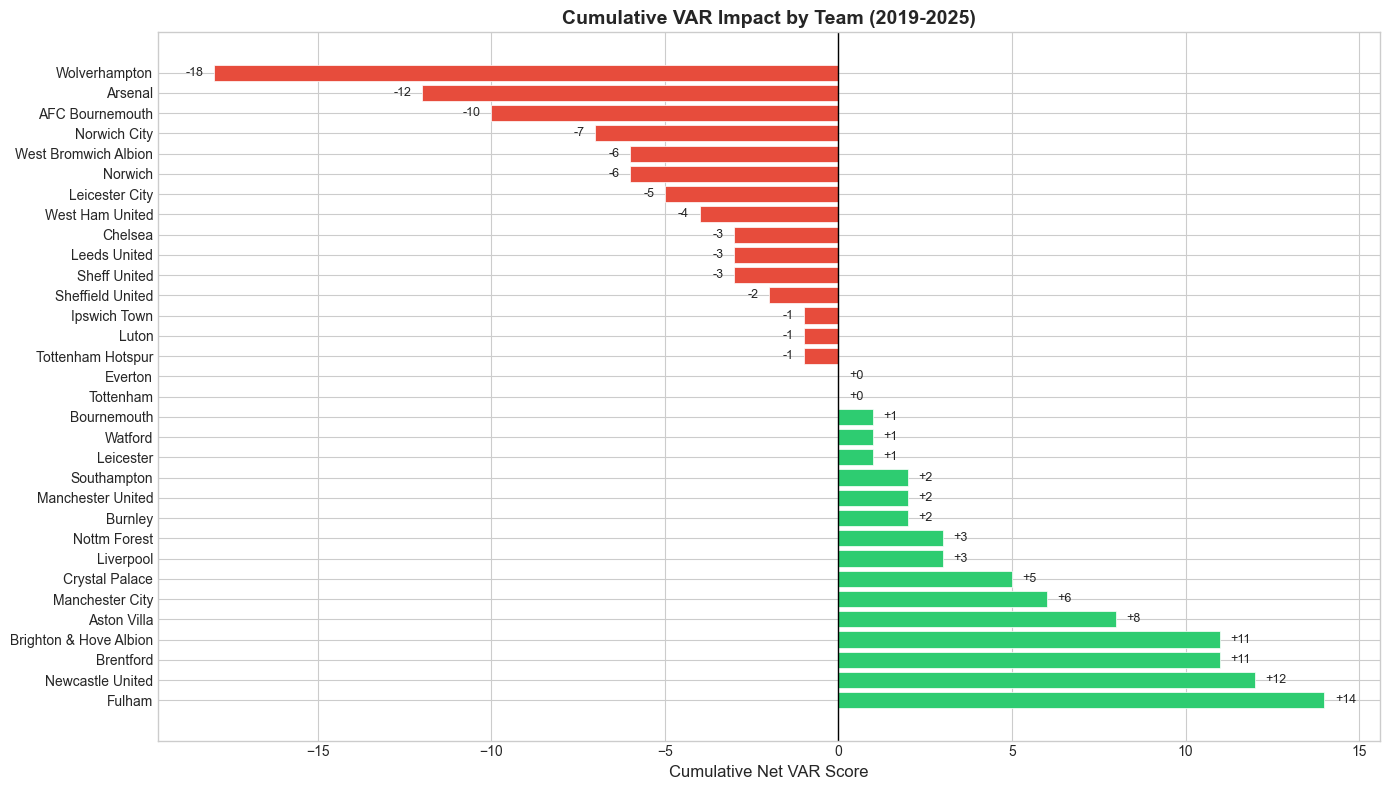

💾 Saved to images/var_cumulative_impact.png


In [33]:
# Visualization: Cumulative VAR Impact
fig, ax = plt.subplots(figsize=(14, 8))

colors = ['#2ecc71' if x >= 0 else '#e74c3c' for x in team_totals['net_score']]
bars = ax.barh(team_totals.index, team_totals['net_score'], color=colors, edgecolor='white', linewidth=0.5)

ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('Cumulative Net VAR Score', fontsize=12)
ax.set_title('Cumulative VAR Impact by Team (2019-2025)', fontsize=14, fontweight='bold')

# Add value labels
for bar, val in zip(bars, team_totals['net_score']):
    x_pos = val + 0.3 if val >= 0 else val - 0.3
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:+.0f}', 
            va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.savefig('images/var_cumulative_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved to images/var_cumulative_impact.png")

---
## 3. Season-by-Season Heatmap

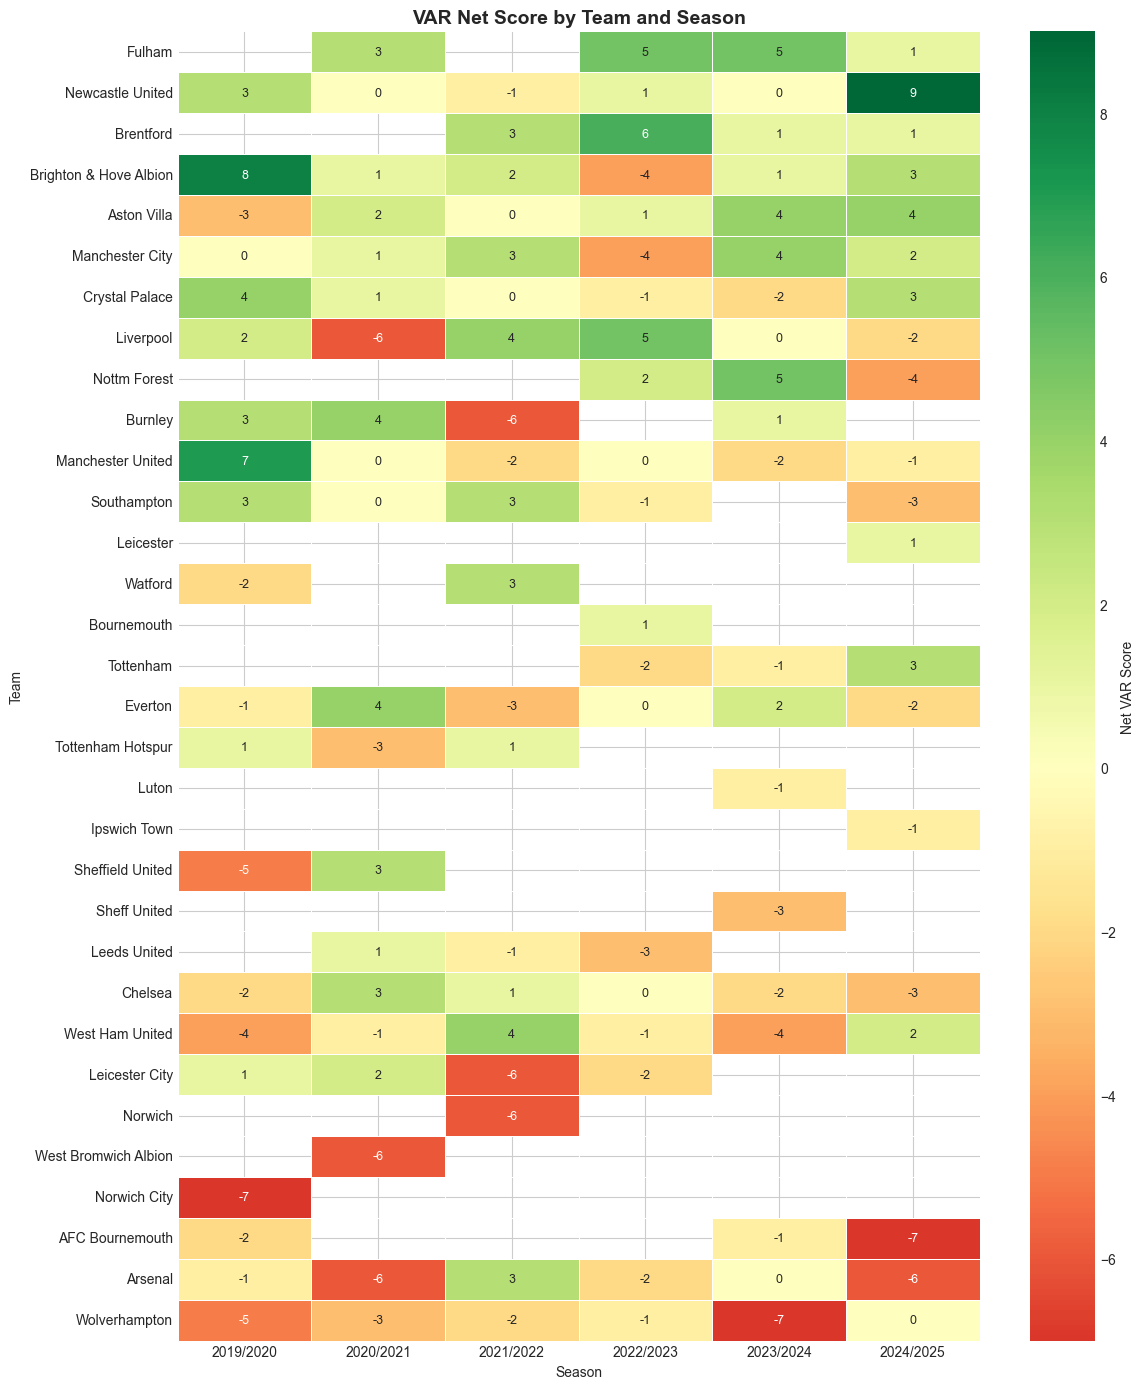

💾 Saved to images/var_heatmap_by_season.png


In [34]:
# Create pivot table for heatmap
pivot = df.pivot_table(index='team_name', columns='year', values='net_score', aggfunc='sum')

# Sort by total net score
pivot['total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('total', ascending=False).drop(columns='total')

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 14))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', center=0, 
            linewidths=0.5, cbar_kws={'label': 'Net VAR Score'},
            annot_kws={'size': 9})
ax.set_title('VAR Net Score by Team and Season', fontsize=14, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Team')
plt.tight_layout()
plt.savefig('images/var_heatmap_by_season.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved to images/var_heatmap_by_season.png")

---
## 4. Big 6 vs Rest Analysis

In [35]:
# Compare Big 6 vs Rest
big6_stats = df.groupby('is_big_6')['net_score'].agg(['mean', 'std', 'sum', 'count'])
big6_stats.index = ['Other Clubs', 'Big 6']

print("🏟️ BIG 6 vs OTHER CLUBS COMPARISON")
print("=" * 50)
display(big6_stats.round(2))

# Statistical test: Is there a significant difference?
big6_scores = df[df['is_big_6']]['net_score']
other_scores = df[~df['is_big_6']]['net_score']

t_stat, p_value = stats.ttest_ind(big6_scores, other_scores)
print(f"\n📊 Independent t-test:")
print(f"   t-statistic: {t_stat:.3f}")
print(f"   p-value: {p_value:.4f}")

if p_value < 0.05:
    print("   ⚠️ Significant difference detected (p < 0.05)")
else:
    print("   ✅ No significant difference (p >= 0.05)")

🏟️ BIG 6 vs OTHER CLUBS COMPARISON


,mean,std,sum,count
Other Clubs,0.06,3.39,5,87
Big 6,-0.15,3.12,-5,33



📊 Independent t-test:
   t-statistic: -0.308
   p-value: 0.7586
   ✅ No significant difference (p >= 0.05)


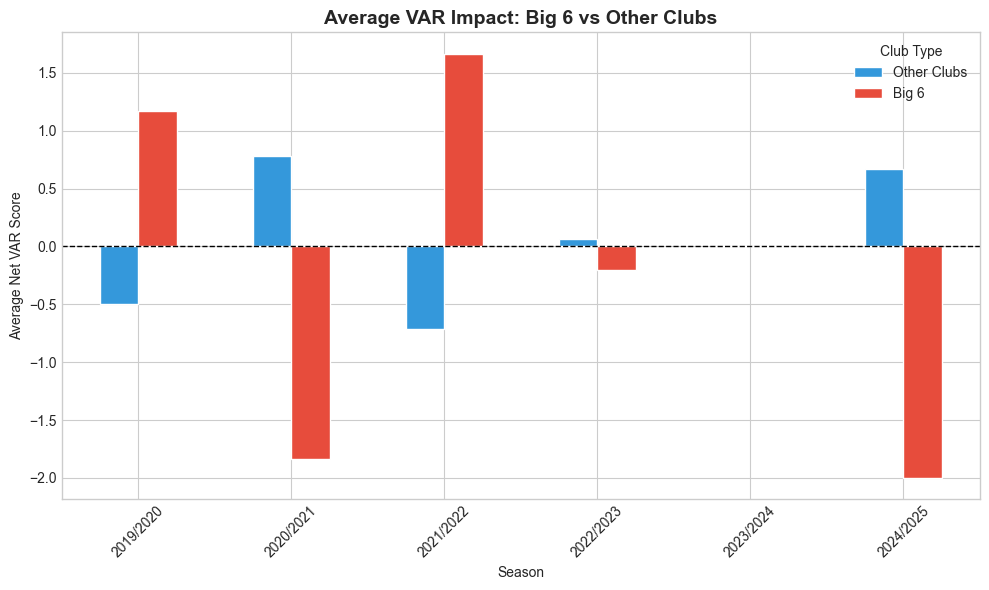

In [36]:
# Visualization: Big 6 vs Rest by Season
big6_by_season = df.groupby(['year', 'is_big_6'])['net_score'].mean().unstack()
big6_by_season.columns = ['Other Clubs', 'Big 6']

fig, ax = plt.subplots(figsize=(10, 6))
big6_by_season.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'], edgecolor='white')
ax.axhline(y=0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Season')
ax.set_ylabel('Average Net VAR Score')
ax.set_title('Average VAR Impact: Big 6 vs Other Clubs', fontsize=14, fontweight='bold')
ax.legend(title='Club Type')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.savefig('images/var_big6_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. VAR Decision Types Breakdown

📋 VAR DECISION TYPES SUMMARY (All Seasons)


,Category,For,Against,Net
0,Goals Awarded,210,210,0
1,Goals Disallowed,293,293,0
2,Penalties,146,146,0
3,Subjective Decisions,363,363,0


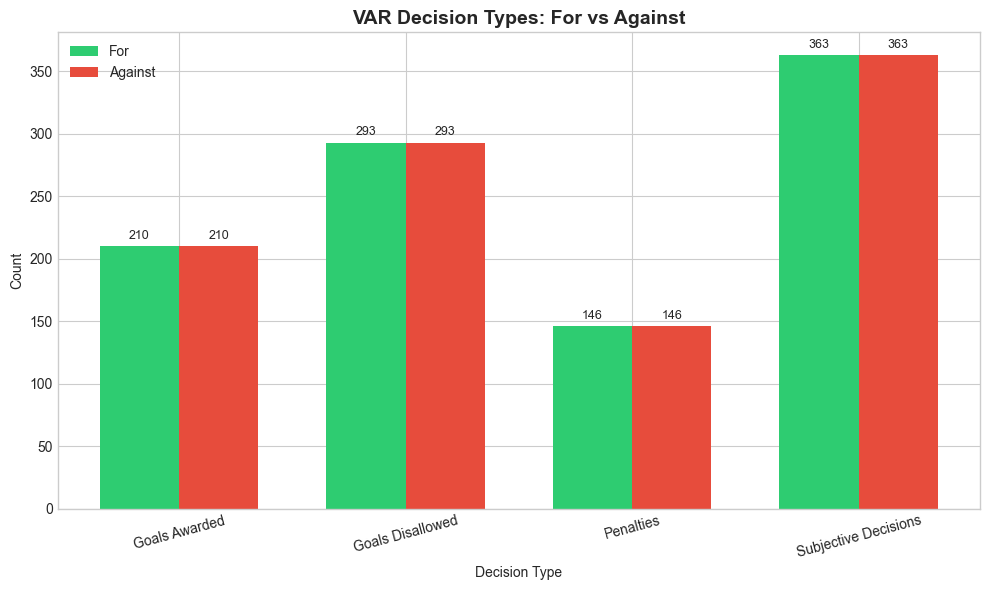

In [37]:
# Aggregate decision types across all seasons
decision_totals = df[['leading_to_goals_for', 'leading_to_goals_against',
                      'disallowed_goals_for', 'disallowed_goals_against',
                      'penalties_for', 'penalties_against',
                      'subj_decisions_for', 'subj_decisions_against']].sum()

# Create a cleaner summary
decision_summary = pd.DataFrame({
    'Category': ['Goals Awarded', 'Goals Disallowed', 'Penalties', 'Subjective Decisions'],
    'For': [decision_totals['leading_to_goals_for'], 
            decision_totals['disallowed_goals_for'],
            decision_totals['penalties_for'],
            decision_totals['subj_decisions_for']],
    'Against': [decision_totals['leading_to_goals_against'], 
                decision_totals['disallowed_goals_against'],
                decision_totals['penalties_against'],
                decision_totals['subj_decisions_against']]
})
decision_summary['Net'] = decision_summary['For'] - decision_summary['Against']

print("📋 VAR DECISION TYPES SUMMARY (All Seasons)")
print("=" * 50)
display(decision_summary)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(decision_summary))
width = 0.35

bars1 = ax.bar(x - width/2, decision_summary['For'], width, label='For', color='#2ecc71')
bars2 = ax.bar(x + width/2, decision_summary['Against'], width, label='Against', color='#e74c3c')

ax.set_xlabel('Decision Type')
ax.set_ylabel('Count')
ax.set_title('VAR Decision Types: For vs Against', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(decision_summary['Category'], rotation=15)
ax.legend()

# Add value labels
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.0f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('images/var_decision_types.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. VAR Impact Trends Over Time

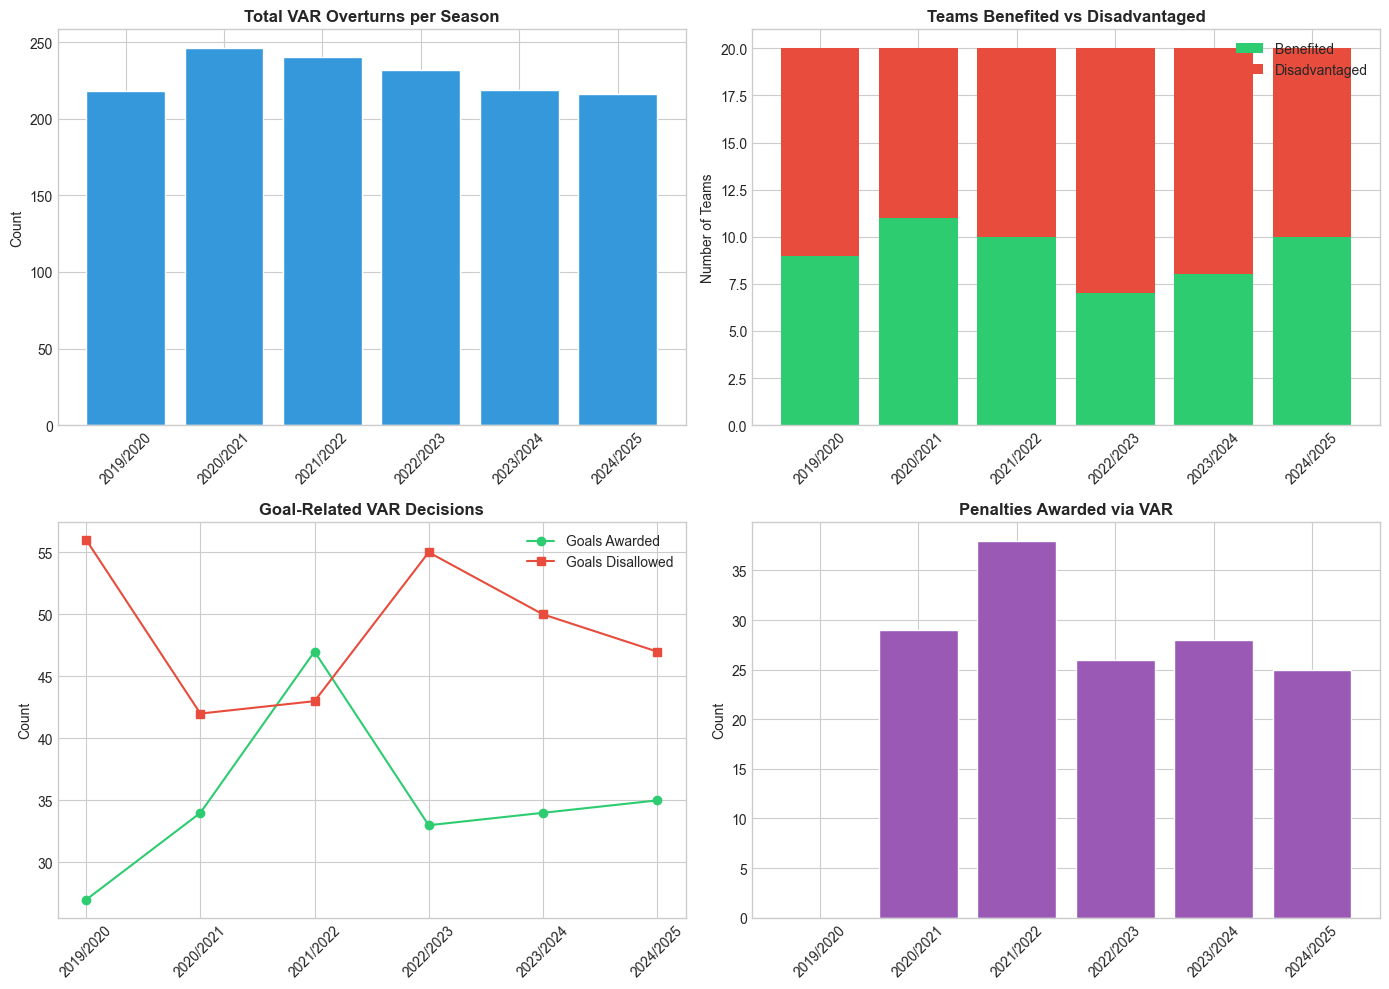

💾 Saved to images/var_trends_over_time.png


In [38]:
# Trends analysis
season_trends = df.groupby('year').agg({
    'overturns_total': 'sum',
    'net_score': lambda x: (x > 0).sum(),  # Teams with positive impact
    'leading_to_goals_for': 'sum',
    'disallowed_goals_for': 'sum',
    'penalties_for': 'sum'
}).rename(columns={'net_score': 'teams_benefited'})

season_trends['goals_decisions'] = season_trends['leading_to_goals_for'] + season_trends['disallowed_goals_for']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Total Overturns per Season
axes[0, 0].bar(season_trends.index, season_trends['overturns_total'], color='#3498db', edgecolor='white')
axes[0, 0].set_title('Total VAR Overturns per Season', fontweight='bold')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Teams Benefited vs Disadvantaged
axes[0, 1].bar(season_trends.index, season_trends['teams_benefited'], color='#2ecc71', label='Benefited')
axes[0, 1].bar(season_trends.index, 20 - season_trends['teams_benefited'], 
               bottom=season_trends['teams_benefited'], color='#e74c3c', label='Disadvantaged')
axes[0, 1].set_title('Teams Benefited vs Disadvantaged', fontweight='bold')
axes[0, 1].set_ylabel('Number of Teams')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Goal-related Decisions
axes[1, 0].plot(season_trends.index, season_trends['leading_to_goals_for'], 'o-', label='Goals Awarded', color='#2ecc71')
axes[1, 0].plot(season_trends.index, season_trends['disallowed_goals_for'], 's-', label='Goals Disallowed', color='#e74c3c')
axes[1, 0].set_title('Goal-Related VAR Decisions', fontweight='bold')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Penalties
axes[1, 1].bar(season_trends.index, season_trends['penalties_for'], color='#9b59b6', edgecolor='white')
axes[1, 1].set_title('Penalties Awarded via VAR', fontweight='bold')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('images/var_trends_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved to images/var_trends_over_time.png")

---
## 7. Interactive Visualizations (Plotly)

In [39]:
if PLOTLY_AVAILABLE:
    # Interactive scatter plot: Net Score vs Total Overturns
    fig = px.scatter(df, x='overturns_total', y='net_score', 
                     color='is_big_6', hover_name='team_name',
                     animation_frame='year', size='overturns_total',
                     color_discrete_map={True: '#e74c3c', False: '#3498db'},
                     labels={'overturns_total': 'Total Overturns', 
                             'net_score': 'Net VAR Score',
                             'is_big_6': 'Big 6 Club'},
                     title='VAR Impact by Team (Animated by Season)')
    fig.add_hline(y=0, line_dash='dash', line_color='gray')
    fig.update_layout(height=600)
    fig.show()
else:
    print("⚠️ Plotly not available. Install with: pip install plotly")

In [40]:
if PLOTLY_AVAILABLE:
    # Interactive heatmap
    pivot_for_plotly = df.pivot_table(index='team_name', columns='year', 
                                       values='net_score', aggfunc='sum').fillna(0)
    pivot_for_plotly['total'] = pivot_for_plotly.sum(axis=1)
    pivot_for_plotly = pivot_for_plotly.sort_values('total', ascending=True).drop(columns='total')
    
    fig = px.imshow(pivot_for_plotly, 
                    color_continuous_scale='RdYlGn',
                    color_continuous_midpoint=0,
                    labels={'color': 'Net VAR Score'},
                    title='VAR Net Score Heatmap (Interactive)')
    fig.update_layout(height=800)
    fig.show()

---
## 8. Key Findings Summary

In [41]:
# Generate automated summary
print("="*60)
print("📊 VAR ANALYSIS KEY FINDINGS")
print("="*60)

# Most benefited team
most_benefited = team_totals['net_score'].idxmax()
most_benefited_score = team_totals['net_score'].max()
print(f"\n🏆 Most Benefited Team: {most_benefited} (Net: +{most_benefited_score:.0f})")

# Most disadvantaged team
most_disadvantaged = team_totals['net_score'].idxmin()
most_disadvantaged_score = team_totals['net_score'].min()
print(f"📉 Most Disadvantaged Team: {most_disadvantaged} (Net: {most_disadvantaged_score:.0f})")

# Big 6 analysis
big6_avg = df[df['is_big_6']]['net_score'].mean()
other_avg = df[~df['is_big_6']]['net_score'].mean()
print(f"\n🏟️ Big 6 Average Net Score: {big6_avg:+.2f}")
print(f"   Other Clubs Average: {other_avg:+.2f}")

# Total overturns
total_overturns = df['overturns_total'].sum()
print(f"\n📈 Total VAR Overturns (All Seasons): {total_overturns}")

# Season with most overturns
overturns_by_season = df.groupby('year')['overturns_total'].sum()
busiest_season = overturns_by_season.idxmax()
print(f"   Busiest Season: {busiest_season} ({overturns_by_season.max()} overturns)")

print("\n" + "="*60)

📊 VAR ANALYSIS KEY FINDINGS

🏆 Most Benefited Team: Fulham (Net: +14)
📉 Most Disadvantaged Team: Wolverhampton (Net: -18)

🏟️ Big 6 Average Net Score: -0.15
   Other Clubs Average: +0.06

📈 Total VAR Overturns (All Seasons): 1371
   Busiest Season: 2020/2021 (246 overturns)



---
## 9. Export Processed Data

In [42]:
# Export processed team totals
team_totals.to_csv('data/var_team_totals_processed.csv')
print("💾 Exported team totals to data/var_team_totals_processed.csv")

# Export pivot table
pivot.to_csv('data/var_by_season_pivot.csv')
print("💾 Exported season pivot to data/var_by_season_pivot.csv")

💾 Exported team totals to data/var_team_totals_processed.csv
💾 Exported season pivot to data/var_by_season_pivot.csv
